# Master Dataset — Construcció i anàlisi de cobertura temporal

Aquest notebook construeix el dataset unificat del sistema agrivoltaic a partir de 12 fonts de dades de sensors independents.

**Flux de treball:**
1. Càrrega i renombrat dels CSV originals
2. Funcions helpers de neteja
3. Anàlisi de freqüència de lectura per sensor
4. Diagnosi de la columna duplicada a `precipitation_intensity`
5. Visualització de cobertura temporal
6. Construcció del Master Dataset amb interpolació

---

## Càrrega de dades i configuració d'entorn

Importa llibreries, defineix els directoris de treball i copia els CSV originals (amb noms llargs) a `./data/` amb noms curts normalitzats.

In [40]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from IPython.display import display
import shutil
import math

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_colwidth', 60)

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

NOTEBOOK_DIR = Path(os.getcwd())           
DATA_DIR     = NOTEBOOK_DIR/ 'data'
OUT_DIR      = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

print(f'DATA_DIR  : {DATA_DIR}')
print(f'OUT_DIR   : {OUT_DIR}')


os.makedirs('./data', exist_ok=True)


files = {
    'AIR_AIR Temperatures (ALL)-data-as-joinbyfield-2026-02-12 08_56_48.csv': 'air_temperature.csv',
    'AIR_ePAR (all parameters)-data-as-joinbyfield-2026-02-12 09_00_37.csv': 'par_radiation.csv',
    'PV_Irradiance-data-as-joinbyfield-2026-02-12 14_17_50.csv':              'pv_irradiance.csv',
    'PV_PV panel temperatures-data-as-joinbyfield-2026-02-12 14_18_22.csv':   'pv_panel_temperature.csv',
    'Precipitation (Total  Difference cumulative sum)-data-2026-02-12 14_23_21.csv': 'precipitation_cumulative.csv',
    'Precipitation-data-as-joinbyfield-2026-02-12 14_21_47.csv':              'precipitation_intensity.csv',
    'Precipitation_type_-data-2026-02-12 09_01_21.csv':                       'precipitation_type.csv',
    'SOIL_Temperature-data-as-joinbyfield-2026-02-12 08_54_57.csv':           'soil_temperature.csv',
    'SOIL_VWC-data-as-joinbyfield-2026-02-12 08_57_18.csv':                   'soil_vwc.csv',
    'Tracking angles-data-as-joinbyfield-2026-02-12 14_24_26.csv':            'tracker_angles.csv',
    'Wind direction-data-2026-02-12 14_25_08.csv':                            'wind_direction.csv',
    'Wind speed-data-2026-02-12 09_05_40.csv':                                'wind_speed.csv',
}

for original, nou in files.items():
    src = f'../data/{original}'
    dst = f'./data/{nou}'
    shutil.copy2(src, dst)
    print(f'{original}\n   -> {nou}\n')

DATA_DIR  : \\wsl.localhost\Ubuntu\home\pablo_laptop\GIA\PIA\PIA_lab\sprint3\data
OUT_DIR   : \\wsl.localhost\Ubuntu\home\pablo_laptop\GIA\PIA\PIA_lab\sprint3\outputs
AIR_AIR Temperatures (ALL)-data-as-joinbyfield-2026-02-12 08_56_48.csv
   -> air_temperature.csv

AIR_ePAR (all parameters)-data-as-joinbyfield-2026-02-12 09_00_37.csv
   -> par_radiation.csv

PV_Irradiance-data-as-joinbyfield-2026-02-12 14_17_50.csv
   -> pv_irradiance.csv

PV_PV panel temperatures-data-as-joinbyfield-2026-02-12 14_18_22.csv
   -> pv_panel_temperature.csv

Precipitation (Total  Difference cumulative sum)-data-2026-02-12 14_23_21.csv
   -> precipitation_cumulative.csv

Precipitation-data-as-joinbyfield-2026-02-12 14_21_47.csv
   -> precipitation_intensity.csv

Precipitation_type_-data-2026-02-12 09_01_21.csv
   -> precipitation_type.csv

SOIL_Temperature-data-as-joinbyfield-2026-02-12 08_54_57.csv
   -> soil_temperature.csv

SOIL_VWC-data-as-joinbyfield-2026-02-12 08_57_18.csv
   -> soil_vwc.csv

Tracking

## Funcions helpers

- **`strip_unit`**: extreu el valor numèric de strings com `'28.8 °C'` o `'1024 W/m²'`. Gestiona tant `object` com el nou `StringDtype` de pandas.
- **`detect_sep_line`**: detecta si el CSV té una línia `sep=,` al principi (format Windows) i l'omet.
- **`load_csv`**: carrega qualsevol CSV del projecte de forma robusta (BOM UTF-8, línia sep=, normalitza la columna `Time`).
- **`strip_all_units`**: aplica `strip_unit` a totes les columnes no-temporals d'un DataFrame.

In [41]:
def strip_unit(series: pd.Series) -> pd.Series:
    """Extrae el valor numérico de strings tipo '28.8 °C', '1024 W/m²', '41.4 °'."""
    if series.dtype == object or pd.api.types.is_string_dtype(series):  # <-- añade is_string_dtype
        cleaned = series.astype(str).str.extract(r'([\-\d\.]+)', expand=False)
        return pd.to_numeric(cleaned, errors='coerce')
    return series


def detect_sep_line(filepath: Path) -> int:
    """Devuelve cuántas filas de cabecera extra saltar (0 o 1 si tiene 'sep=')."""
    with open(filepath, 'r', encoding='utf-8-sig') as f:
        first = f.readline().strip()
    return 1 if first.lower().startswith('sep=') else 0


def load_csv(filepath: Path, nrows: int = None) -> pd.DataFrame:
    """Carga un CSV manejando la línea sep= y el BOM UTF-8."""
    skip = detect_sep_line(filepath)
    df = pd.read_csv(
        filepath,
        skiprows=skip,
        encoding='utf-8-sig',
        nrows=nrows,
        low_memory=False
    )
    # Normalizar la columna temporal
    time_cols = [c for c in df.columns if c.strip().lower() == 'time']
    if time_cols:
        df = df.rename(columns={time_cols[0]: 'Time'})
        df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
    return df


def strip_all_units(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica strip_unit a todas las columnas no-Time."""
    df = df.copy()
    for col in df.columns:
        if col != 'Time':
            df[col] = strip_unit(df[col])
    return df

# Bounds físicos por sensor — valores fuera de rango son errores de sensor
PHYSICAL_BOUNDS = {
    'air_temperature':          {'min': -20,  'max': 60},    # °C
    'par_radiation':            {'min': 0,    'max': 3000},  # µmol/m²/s
    'pv_irradiance':            {'min': 0,    'max': 1500},  # W/m²
    'pv_panel_temperature':     {'min': -20,  'max': 90},    # °C
    'precipitation_cumulative': {'min': 0,    'max': None},  # mm (solo min)
    'precipitation_intensity':  {'min': 0,    'max': 200},   # mm/h
    'soil_temperature':         {'min': -10,  'max': 50},    # °C
    'soil_vwc':                 {'min': 0,    'max': 100},   # % (sensor reporta 0-100%; strip_unit extrae el numero)
    'tracker_angles':           {'min': -60,  'max': 60},    # grados
    'wind_direction':           {'min': 0,    'max': 360},   # grados
    'wind_speed':               {'min': 0,    'max': 150},   # km/h
}

def apply_physical_bounds(df: pd.DataFrame, sensor_key: str) -> pd.DataFrame:
    """Reemplaza por NaN los valores fuera de bounds físicos (errores de sensor)."""
    bounds = PHYSICAL_BOUNDS.get(sensor_key)
    if bounds is None:
        return df
    df = df.copy()
    for col in df.columns:
        if col == 'Time':
            continue
        
        min_bound = bounds.get('min', -np.inf)
        max_bound = bounds.get('max', np.inf)
        
        # Clip ajusta tot el que baixa del min al min, i el que puja del max al max.
        df[col] = df[col].clip(lower=min_bound, upper=max_bound)
    return df


## Freqüència de lectura per sensor

Calcula la mediana dels intervals entre registres de cada sensor. Això és crític per a la construcció del Master Dataset: cada sensor té el seu propi ritme de mostreig (de 30s fins a 12h), i cal conèixer-lo per detectar huecos reals i definir el límit d'interpolació.

> **Nota:** `precipitation_type` s'ha exclòs del diccionari `SENSORS` per no tenir utilitat analítica directa tenint les altres variables de precipitació.

In [42]:
SENSORS = {
    'air_temperature':         'temp_aire',
    'par_radiation':           'rad_PAR',
    'pv_irradiance':           'irrad_PV',
    'pv_panel_temperature':    'temp_panel_PV',
    'precipitation_cumulative':'precip_acum',
    'precipitation_intensity': 'precip_intens',
    #'precipitation_type':      'tipo_precip', -> de momento quito Precipitation Type, no le veo la utilidad teniendo las otras variables de precipitation
    'soil_temperature':        'temp_suelo',
    'soil_vwc':                'vwx_suelo',
    'tracker_angles':          'tracker_angles',
    'wind_direction':          'dir_viento',
    'wind_speed':              'vel_viento',
}


for i, (key, label) in enumerate(SENSORS.items()):
    path = DATA_DIR / f'{key}.csv'
    if not path.exists():
        continue
    df = load_csv(path)
    df = df.dropna(subset=['Time']).set_index('Time').sort_index()
    if df.empty:
        continue

    median = df.index.to_series().diff().dropna().median()
    print(f"{label:25s} - intervalo entre lecturas: {median}")

temp_aire                 - intervalo entre lecturas: 0 days 06:00:00
rad_PAR                   - intervalo entre lecturas: 0 days 06:00:00
irrad_PV                  - intervalo entre lecturas: 0 days 02:00:00
temp_panel_PV             - intervalo entre lecturas: 0 days 02:00:00
precip_acum               - intervalo entre lecturas: 0 days 00:00:30
precip_intens             - intervalo entre lecturas: 0 days 00:00:30
temp_suelo                - intervalo entre lecturas: 0 days 06:00:00
vwx_suelo                 - intervalo entre lecturas: 0 days 06:00:00
tracker_angles            - intervalo entre lecturas: 0 days 06:00:00
dir_viento                - intervalo entre lecturas: 0 days 12:00:00
vel_viento                - intervalo entre lecturas: 0 days 06:00:00


In [43]:
df_pt = load_csv(DATA_DIR / 'precipitation_type.csv')
print(df_pt.dtypes)
print(df_pt.head(5))
print(df_pt.iloc[:, 1].value_counts().head(10))

for key, label in SENSORS.items():
    path = DATA_DIR / f'{key}.csv'
    if not path.exists():
        continue
    df = load_csv(path)
    df = strip_all_units(df)
    df = df.dropna(subset=['Time']).set_index('Time').sort_index()
    if df.empty:
        continue

    data_cols = [c for c in df.columns]
    # Filas donde TODAS las columnas son null
    all_null = df[data_cols].isna().all(axis=1)
    
    first_real = df.index[~all_null][0]  if (~all_null).any() else None
    last_real  = df.index[~all_null][-1] if (~all_null).any() else None
    n_leading  = all_null[:first_real].sum() if first_real else len(df)
    n_trailing = all_null[last_real:].sum()  if last_real  else len(df)

    
    print(f"{label:20s} | inicio CSV: {df.index[0].date()} → primer dato real: {first_real.date() if first_real else '—'} ({n_leading} filas vacías al inicio)")
    print(f"{'':20s} | fin CSV:    {df.index[-1].date()} → último dato real:  {last_real.date() if last_real else '—'} ({n_trailing} filas vacías al final)")
    print()

Time                  datetime64[us]
Precipitation Type               str
dtype: object
                 Time Precipitation Type
0 2025-06-16 11:55:30   No precipitation
1 2025-06-18 15:11:00   No precipitation
2 2025-06-18 15:11:30   No precipitation
3 2025-06-18 15:12:00   No precipitation
4 2025-06-18 15:12:30   No precipitation
Precipitation Type
No precipitation               571201
Liquid precipitation (rain)     33347
Solid precipitation (snow)        371
sleet                              91
Name: count, dtype: int64
temp_aire            | inicio CSV: 2025-02-12 → primer dato real: 2025-06-16 (496 filas vacías al inicio)
                     | fin CSV:    2026-02-12 → último dato real:  2026-02-12 (0 filas vacías al final)

rad_PAR              | inicio CSV: 2025-02-12 → primer dato real: 2025-06-18 (505 filas vacías al inicio)
                     | fin CSV:    2026-02-12 → último dato real:  2026-02-12 (0 filas vacías al final)

irrad_PV             | inicio CSV: 2025-05-12 →

## Diagnosi de `precipitation_intensity`

El CSV de precipitació té dues columnes amb el mateix nom (`Precipitation Intensity`), que pandas renombra automàticament com `.1`. S'analitza si contenen informació diferent o complementària.

In [44]:
prep_int = DATA_DIR / 'precipitation_intensity.csv'

df = load_csv(prep_int).dropna(subset=['Time']).set_index('Time').sort_index()
print(df.columns.tolist())
print(df.shape)
df.head()

a = df['Precipitation Intensity']
b = df['Precipitation Intensity.1']

# Casos
both_null   = a.isna() & b.isna()
only_a      = a.notna() & b.isna()
only_b      = a.isna() & b.notna()
both_diff   = a.notna() & b.notna() & (a != b)
both_equal  = a.notna() & b.notna() & (a == b)

print(f"Ambas null:          {both_null.sum():>8,}")
print(f"Solo columna A:      {only_a.sum():>8,}")
print(f"Solo columna B:      {only_b.sum():>8,}")
print(f"Ambas, valores ≠:    {both_diff.sum():>8,}")
print(f"Ambas, valores =:    {both_equal.sum():>8,}")
print(f"{'─'*30}")
print(f"Total filas:         {len(df):>8,}")

['Precipitation Intensity', 'Precipitation Intensity.1']
(605682, 2)
Ambas null:                 0
Solo columna A:       427,198
Solo columna B:       141,452
Ambas, valores ≠:           0
Ambas, valores =:      37,032
──────────────────────────────
Total filas:          605,682


### Fusió de les columnes duplicades

Com que les dues columnes mai difereixen quan ambdues tenen valor (`both_diff = 0`), es fusionen amb `combine_first`: agafa el valor de la columna A i, on A és null, usa B. El resultat és una sola columna sense nulls. El CSV es sobreescriu.

In [45]:
df['Precipitation Intensity'] = a.combine_first(b)
df = df.drop(columns=['Precipitation Intensity.1'])

print(f"Nulos restantes: {df['Precipitation Intensity'].isna().sum():,}")
print(df.shape)

df.to_csv(prep_int, index=True)
print(f"Guardado en {prep_int}")

Nulos restantes: 0
(605682, 1)
Guardado en \\wsl.localhost\Ubuntu\home\pablo_laptop\GIA\PIA\PIA_lab\sprint3\data\precipitation_intensity.csv


## Cobertura temporal per sensor

Visualització tipus Gantt: cada sensor és una línia horitzontal des del seu **primer registre real** fins a l'últim. Els huecos (salts > 2× l'interval típic del sensor) es marquen en vermell.

**Important:** s'exclouen les files on totes les columnes de dades són null, que apareixien al principi de molts CSV abans que el sensor comencés a registrar.

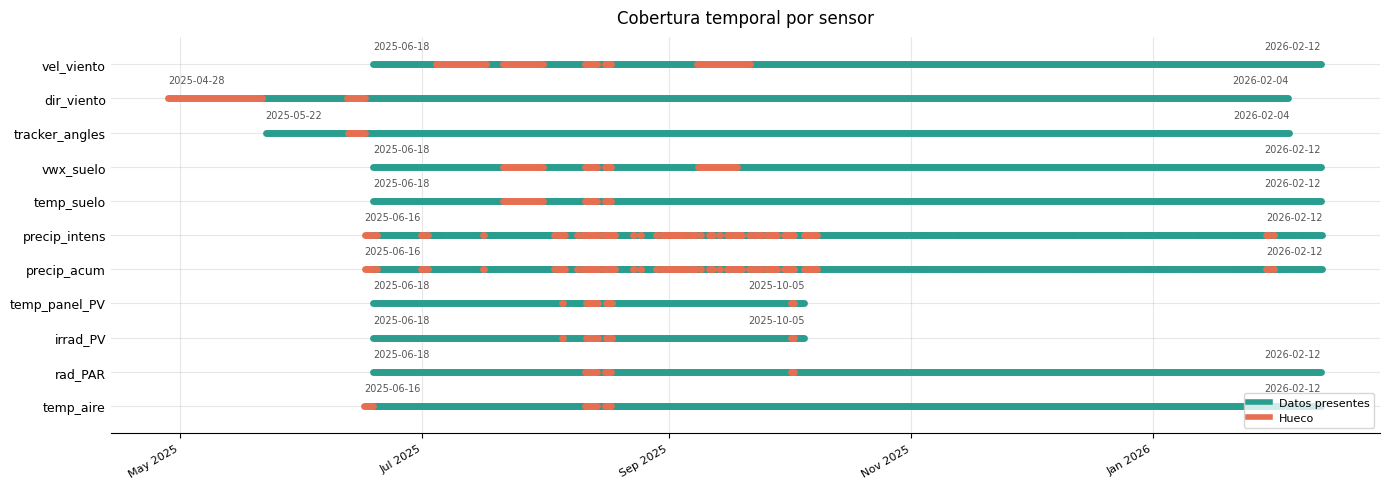

In [46]:
fig, ax = plt.subplots(figsize=(14, 5))

labels_plotted = []

for i, (key, label) in enumerate(SENSORS.items()):
    path = DATA_DIR / f'{key}.csv'
    if not path.exists():
        continue
    df = load_csv(path).dropna(subset=['Time']).set_index('Time').sort_index()
    if df.empty:
        continue

    # ── CAMBIO 1: recortar filas donde todos los valores son null ──
    all_null = df.isna().all(axis=1)
    df = df[~all_null]
    if df.empty:
        continue

    first_real = df.index[0]
    last_real  = df.index[-1]

    median    = df.index.to_series().diff().dropna().median()
    threshold = 2 * median
    diffs     = df.index.to_series().diff()
    gap_mask  = diffs > threshold
    segment_id = gap_mask.cumsum()

    for seg, group in df.groupby(segment_id):
        ax.plot([group.index[0], group.index[-1]], [i, i],
                lw=5, solid_capstyle='round', color='#2A9D8F', zorder=2)

    for gap_end in df.index[gap_mask]:
        gap_start = df.index[df.index.get_loc(gap_end) - 1]
        ax.plot([gap_start, gap_end], [i, i],
                lw=5, solid_capstyle='round', color='#E76F51', zorder=3)

    # ── CAMBIO 2: fechas usando first_real / last_real ──
    ax.text(first_real, i + 0.38, first_real.strftime('%Y-%m-%d'),
            fontsize=7, color='#555', ha='left', va='bottom')
    ax.text(last_real,  i + 0.38, last_real.strftime('%Y-%m-%d'),
            fontsize=7, color='#555', ha='right', va='bottom')

    labels_plotted.append(label)

ax.set_yticks(range(len(labels_plotted)))
ax.set_yticklabels(labels_plotted, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_title('Cobertura temporal por sensor', fontsize=12, pad=10)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', length=0)
ax.set_ylim(-0.8, len(labels_plotted) - 0.2)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='#2A9D8F', lw=4, label='Datos presentes'),
    Line2D([0], [0], color='#E76F51', lw=4, label='Hueco'),
], fontsize=8, loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'cobertura_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## Definició de la política d'interpolació

El Master Dataset tindrà freqüència base de **10 minuts** (freqüència de decisió del tracker).
A 30s el dataset seria ~20× més gran sense informació extra: les variables clau (Tsoil, VWC, PAR) canvien
en escala de minuts, i el RL necessita un timestep que coincideixi amb la freqüència de decisió de control.

| Política | Sensors | Justificació |
|---|---|---|
| `linear` | temperatures aire, panell PV, sòl | Variables que canvien gradualment |
| `ffill` | precipitació acumulada | Manté l'últim valor conegut sense inventar transicions |
| `circular` | direcció del vent | Variable angular: interpola sin/cos, no el grau directament |
| `mean + pvlib` | tracker angles | Buits es completen amb referència física pvlib |
| `derived` | precipitació intensitat | Derivada de `precip_cumulative.diff() / 10min` (més estable) |

**Límit d'interpolació:** màxim 2× l'interval típic del sensor. Més enllà és un forat real → `NaN`.

**Outliers:** s'apliquen bounds físics per sensor (`apply_physical_bounds`) *abans* d'interpolar,
per evitar que errors de sensor es propaguin via interpolació.


In [47]:
SENSOR_INFO = {
    'air_temperature':          {'interval_s': 6*3600,  'interp': 'linear'},
    'par_radiation':            {'interval_s': 6*3600,  'interp': 'pchip'},
    'pv_irradiance':            {'interval_s': 2*3600,  'interp': 'pchip'},
    'pv_panel_temperature':     {'interval_s': 2*3600,  'interp': 'linear'},
    'precipitation_cumulative': {'interval_s': 30,      'interp': 'ffill'},
    'precipitation_intensity':  {'interval_s': 30,      'interp': 'derived'},  # derivada de cumulative
    'precipitation_type':       {'interval_s': 30,      'interp': 'none'},
    'soil_temperature':         {'interval_s': 6*3600,  'interp': 'linear'},
    'soil_vwc':                 {'interval_s': 6*3600,  'interp': 'linear'},
    'tracker_angles':           {'interval_s': 6*3600,  'interp': 'linear'},
    'wind_direction':           {'interval_s': 12*3600, 'interp': 'circular'},  # variable angular
    'wind_speed':               {'interval_s': 6*3600,  'interp': 'linear'},
}


## Construcció del Master Dataset

Join de tots els sensors sobre un índex temporal comú de 30 segons:
1. Es calcula el rang global usant el **primer i últim registre real** de cada sensor (excloent files tot-null)
2. Es calculen variables solars amb `pvlib` (posició solar, clearsky i tracker teòric)
3. Cada sensor es reindexat a l'índex base i s'aplica la seva política d'interpolació
   - `tracker_angles`: interpolació millorada amb suport físic (`tracker_theta` teòric)
4. `tracker_angles` es transforma a una sola variable (`tracker_angle_grouped`) per evitar 10 columnes redundants
5. Les columnes es prefixen amb el nom del sensor (`sensor__columna`) per evitar col·lisions de noms
6. Es construeix una versió **compacta** orientada a control (1 acció global de rotació)
7. El resultat compactat es desa a `outputs/master_dataset.csv`

### Justificació breu de la compactació
- Es mantenen variables amb valor causal per al control (`R1`, `S1`, `S2`, meteo exògena i `GPOA`).
- Es redueixen canals fortament redundants (p.ex. PAR `cal_out_16bit` i `immersed`) i es fa agregació per zona.
- Es conserven **deltas vs R1** per aïllar l'efecte de les plaques sobre sòl i radiació.
- Es genera un mapa de correlació per visualitzar redundància dins del conjunt final.

El Master Dataset començarà a partir de: 2025-06-17 14:00:00
Shape master raw: (34563, 84)
Rango: 2025-06-17 14:00:00 → 2026-02-12 14:20:00

Nulos por columna (raw):
air_temperature__R1d40_Z8AI.air.T.degC                                  5647
air_temperature__WS100.Air.TempAct.degC                                  608
air_temperature__WS100.Air.TempAvg.degC                                  608
air_temperature__WS100.Air.TempMax.degC                                  608
air_temperature__WS100.Air.TempMin.degC                                  608
air_temperature__WS100.Heating.Temperature.degC                          681
air_temperature__R1d40_Z8AI.air.T.degC.1                                5647
air_temperature__S1d10_Z8AI.air.T__center.degC                           681
air_temperature__S1d10_Z8AI.air.T__east.degC                             681
air_temperature__S1d10_Z8AI.air.T__west.degC                             681
air_temperature__S2d30_Z8AI.air.T__east.degC                    

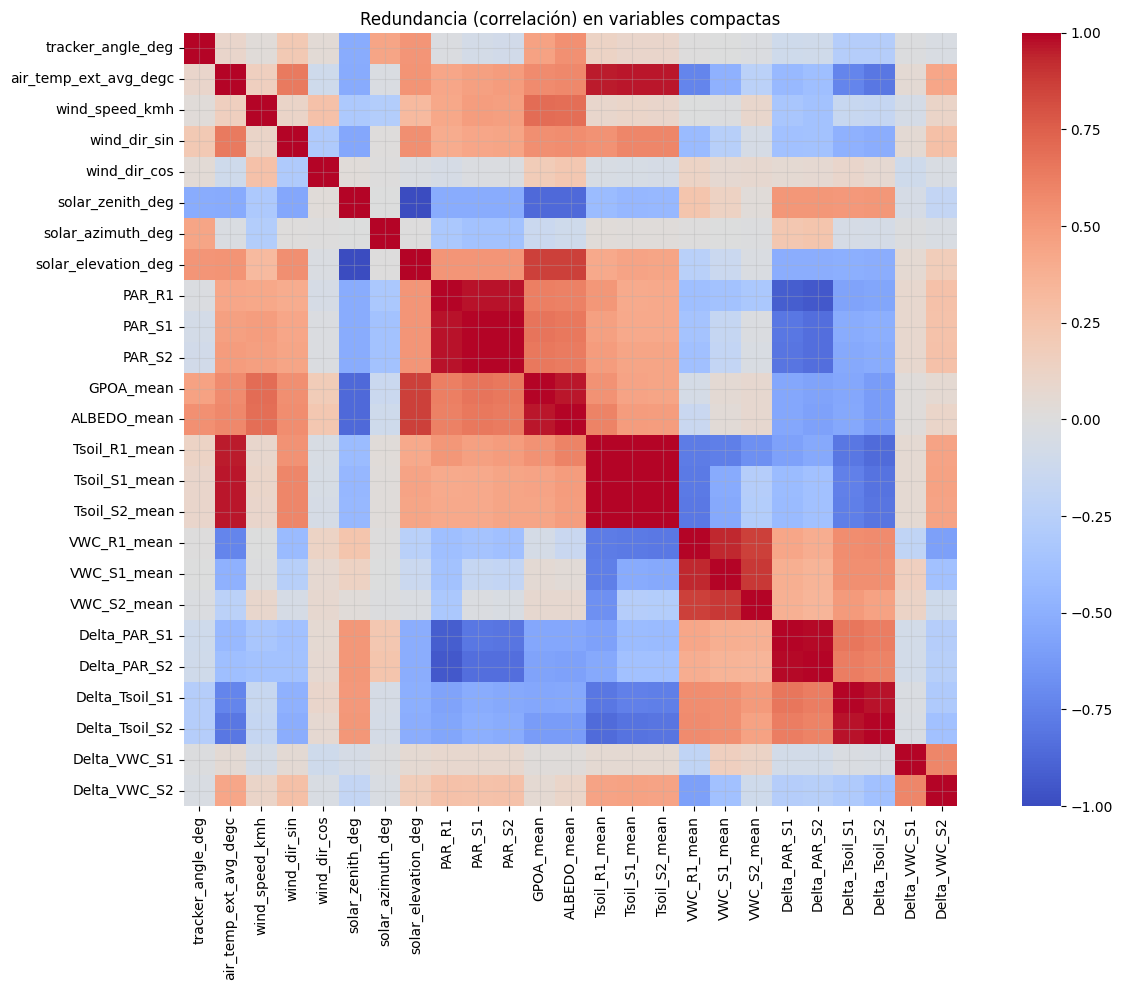

Guardado COMPACT en \\wsl.localhost\Ubuntu\home\pablo_laptop\GIA\PIA\PIA_lab\sprint3\outputs\master_dataset.csv


In [54]:
BASE_FREQ   = '10min'
BASE_FREQ_S = 600   # 10 minutos en segundos

# L'inici real de la fase operativa unificada
GLOBAL_START_TIME = pd.Timestamp('2025-06-17 14:00:00')

SITE_LAT = 41.2778   # Castelldefels
SITE_LON = 1.9706
SITE_TZ  = 'Europe/Madrid'
TRACKER_MAX_ANGLE = 60
TRACKER_GCR = 0.35

# Índice base: primer y último dato REAL de cada sensor (sin filas todo-null)
all_starts, all_ends = [], []
for key in SENSOR_INFO:
    path = DATA_DIR / f'{key}.csv'
    if not path.exists():
        continue
    df = load_csv(path).dropna(subset=['Time']).set_index('Time').sort_index()
    all_null = df.isna().all(axis=1)
    df = df[~all_null]
    if df.empty:
        continue
    all_starts.append(df.index[0])
    all_ends.append(df.index[-1])

# --- NOU TALL TEMPORAL ---
# L'inici del dataset serà el més tardà entre l'inici real calculat 
# i la teva data GLOBAL_START_TIME per evitar descartar erròniament.
# Com que GLOBAL_START_TIME (17 de juny) és posterior a min(all_starts) (22 de maig),
# el dataset començarà el 17 de juny.
final_start = max(min(all_starts), GLOBAL_START_TIME)

# Creem l'índex mestre amb la nova data d'inici
master_index = pd.date_range(final_start, max(all_ends), freq=BASE_FREQ)
master = pd.DataFrame(index=master_index)
master.index.name = 'Time'

print(f"El Master Dataset començarà a partir de: {master_index[0]}")
# Variables solares (pvlib) sobre el índice maestro
try:
    from pvlib.location import Location
    import pvlib.tracking as pv_tracking
except ModuleNotFoundError as e:
    raise ModuleNotFoundError("pvlib no está instalado. Instala con: pip install pvlib") from e

site = Location(latitude=SITE_LAT, longitude=SITE_LON, tz=SITE_TZ, altitude=0)
ts_local = master_index.tz_localize(SITE_TZ, ambiguous='NaT', nonexistent='shift_forward')
solar_pos = site.get_solarposition(ts_local)
cs = site.get_clearsky(ts_local, model='ineichen')
# tracker_theta_theoretical_deg eliminat: pvlib asumeix eix N-S,
# però el sistema és E-O → la columna és físicament incorrecta.
# La interpolació de buits del tracker usarà solar_elevation com a referència.
solar_df = pd.DataFrame(index=master_index)
solar_df['solar_zenith_deg'] = solar_pos['apparent_zenith'].to_numpy()
solar_df['solar_azimuth_deg'] = solar_pos['azimuth'].to_numpy()
solar_df['solar_elevation_deg'] = 90 - solar_df['solar_zenith_deg']
solar_df['clearsky_ghi_wm2'] = cs['ghi'].to_numpy()
solar_df['clearsky_dni_wm2'] = cs['dni'].to_numpy()
solar_df['clearsky_dhi_wm2'] = cs['dhi'].to_numpy()

# Merge de cada sensor
for key, info in SENSOR_INFO.items():
    path = DATA_DIR / f'{key}.csv'
    if not path.exists():
        continue

    df = load_csv(path)
    df = strip_all_units(df)
    df = df.dropna(subset=['Time']).set_index('Time').sort_index()
    df = df[~df.index.duplicated(keep='first')]

    # ── CAMBIO: aplicar bounds físicos ANTES de interpolar ──────────────
    df = apply_physical_bounds(df, key)

    # Trackers: desde 18-06-2025 se agregan en una única rotación
    if key == 'tracker_angles':
        tracker_cols = [c for c in df.columns if 'tracker_M' in c]
        if tracker_cols:
            tracker_mean = df[tracker_cols].mean(axis=1)
            tracker_ref = df[tracker_cols[0]]
            grouped = tracker_mean.copy()
            grouped.loc[grouped.index < TRACKER_AGG_START] = tracker_ref.loc[grouped.index < TRACKER_AGG_START].combine_first(
                tracker_mean.loc[grouped.index < TRACKER_AGG_START]
            )
            df = pd.DataFrame({'tracker_angle_grouped': grouped}, index=df.index)
        else:
            continue

    # ── CAMBIO: wind_direction — convertir a componentes circulares ──────
    if key == 'wind_direction':
        wind_col = [c for c in df.columns][0]
        angle_rad = np.radians(df[wind_col])
        df['wind_dir_sin'] = np.sin(angle_rad)
        df['wind_dir_cos'] = np.cos(angle_rad)
        df = df.drop(columns=[wind_col])  # elimina el grado, se reconstruye al final

    # Recortar filas todo-null antes de reindexar
    all_null = df.isna().all(axis=1)
    df = df[~all_null]
    if df.empty:
        continue

    limit_steps = max(1, int((2 * info['interval_s']) / BASE_FREQ_S))
    df = df.reindex(master.index)

    for col in df.columns:
        df[col] = strip_unit(df[col])

        # ── CAMBIO: precipitation_intensity se marca como 'derived', se calcula después ──
        if info['interp'] == 'derived':
            continue  # se calcula post-merge desde precipitation_cumulative

        # Lógica de interpolación aplicada según SENSOR_INFO
        if info['interp'] == 'linear':
            # Trackers: interpolación mejorada con referencia física (pvlib)
            if key == 'tracker_angles' and col == 'tracker_angle_grouped':
                obs = df[col].copy()
                # Fallback E-O: regressió lineal sobre solar_elevation
                # (r=0.44 observat, físicament coherent per a eix horitzontal E-O)
                elev_ref = solar_df['solar_elevation_deg'].reindex(df.index)
                overlap = obs.notna() & elev_ref.notna()
                if overlap.sum() > 30:
                    coeffs = np.polyfit(elev_ref[overlap].values, obs[overlap].values, deg=1)
                    elev_cal = coeffs[0] * elev_ref + coeffs[1]
                else:
                    elev_cal = pd.Series(np.nan, index=df.index)

                # 1) huecos curts: interpolació temporal
                interp_short = obs.interpolate(method='time', limit=limit_steps, limit_direction='forward')

                # 2) huecos restants: referència solar calibrada E-O
                miss = interp_short.isna() & elev_cal.notna()
                interp_short.loc[miss] = elev_cal.loc[miss]

                # 3) límits físics del tracker
                df[col] = interp_short.clip(lower=-TRACKER_MAX_ANGLE, upper=TRACKER_MAX_ANGLE)
            else:
                df[col] = df[col].interpolate(method='time', limit=limit_steps,
                                              limit_direction='forward')

        # ── CAMBIO: wind_direction circular — interpola sin/cos independientemente ──
        elif info['interp'] == 'circular':
            df[col] = df[col].interpolate(method='time', limit=limit_steps, limit_direction='forward')

        elif info['interp'] == 'ffill':
            df[col] = df[col].ffill(limit=limit_steps)
        elif info['interp'] == 'pchip':
            df[col] = df[col].interpolate(method='pchip', limit=limit_steps).clip(lower=0)

    master = master.join(df.add_prefix(f'{key}__'), how='left')

# ── CAMBIO: reconstruir ángulo de viento desde sin/cos + derivar precip_intensity ──
sin_col = [c for c in master.columns if c.startswith('wind_direction__') and 'sin' in c]
cos_col = [c for c in master.columns if c.startswith('wind_direction__') and 'cos' in c]
if sin_col and cos_col:
    master['wind_direction__angle_deg'] = np.degrees(
        np.arctan2(master[sin_col[0]], master[cos_col[0]])
    ) % 360  # reconstruido solo para visualización/diagnóstico

# Derivar precipitation_intensity desde cumulative (más estable que la columna raw)
cum_col = [c for c in master.columns if c.startswith('precipitation_cumulative__')]
if cum_col:
    # diff() en minutos: BASE_FREQ_S / 60 = 10 min
    master['precipitation_cumulative__intensity_derived_mm_per_10min'] = (
        master[cum_col[0]].diff().clip(lower=0)  # clip: la acumulada solo sube
    )

print(f"Shape master raw: {master.shape}")
print(f"Rango: {master.index[0]} → {master.index[-1]}")
print(f"\nNulos por columna (raw):")
print(master.isna().sum().to_string())

# ============================================================
# Compactación orientada a control (1 acción: ángulo global)
# ============================================================
master_raw = master.copy()
master_raw = master_raw.join(solar_df, how='left')

def _mean_cols(df, cols):
    return df[cols].mean(axis=1) if cols else np.nan

def _std_cols(df, cols):
    return df[cols].std(axis=1) if cols else np.nan

compact = pd.DataFrame(index=master_raw.index)

# Acción única
compact['tracker_angle_deg'] = master_raw.get('tracker_angles__tracker_angle_grouped', np.nan)

# Meteo exógena
compact['air_temp_ext_avg_degc'] = master_raw.get('air_temperature__WS100.Air.TempAvg.degC', np.nan)
compact['wind_speed_kmh'] = master_raw.get('wind_speed__R1d40_Z8AI.air.WS.kmh', np.nan)

# ── CAMBIO: viento como sin/cos (no el grado) — correcto para modelos ──
if sin_col and cos_col:
    compact['wind_dir_sin'] = master_raw[sin_col[0]]
    compact['wind_dir_cos'] = master_raw[cos_col[0]]
    # El ángulo reconstruido solo para diagnóstico humano, no entra en features del MDP
    compact['wind_direction_deg_display'] = master_raw.get('wind_direction__angle_deg', np.nan)

# ── CAMBIO: usar intensidad derivada en vez de la columna raw ──
compact['precip_intensity_mm10min'] = master_raw.get(
    'precipitation_cumulative__intensity_derived_mm_per_10min', np.nan)
compact['precip_cumulative'] = master_raw.get(
    'precipitation_cumulative__Precipitation Difference (Cumulative sum)', np.nan)

compact['solar_zenith_deg'] = master_raw.get('solar_zenith_deg', np.nan)
compact['solar_azimuth_deg'] = master_raw.get('solar_azimuth_deg', np.nan)
compact['solar_elevation_deg'] = master_raw.get('solar_elevation_deg', np.nan)
compact['clearsky_ghi_wm2'] = master_raw.get('clearsky_ghi_wm2', np.nan)
compact['clearsky_dni_wm2'] = master_raw.get('clearsky_dni_wm2', np.nan)
compact['clearsky_dhi_wm2'] = master_raw.get('clearsky_dhi_wm2', np.nan)
# PAR (solo cal_out, sin 16bit)
par_r1 = [c for c in master_raw.columns if c.startswith('par_radiation__R1') and 'cal_out' in c and '16bit' not in c]
par_s1 = [c for c in master_raw.columns if c.startswith('par_radiation__S1') and 'cal_out' in c and '16bit' not in c]
par_s2 = [c for c in master_raw.columns if c.startswith('par_radiation__S2') and 'cal_out' in c and '16bit' not in c]
compact['PAR_R1'] = _mean_cols(master_raw, par_r1)
compact['PAR_S1'] = _mean_cols(master_raw, par_s1)
compact['PAR_S2'] = _mean_cols(master_raw, par_s2)

# Suelo temperatura por zona
soil_t_r1 = [c for c in master_raw.columns if c.startswith('soil_temperature__R1')]
soil_t_s1 = [c for c in master_raw.columns if c.startswith('soil_temperature__S1')]
soil_t_s2 = [c for c in master_raw.columns if c.startswith('soil_temperature__S2')]
compact['Tsoil_R1_mean'] = _mean_cols(master_raw, soil_t_r1)
compact['Tsoil_S1_mean'] = _mean_cols(master_raw, soil_t_s1)
compact['Tsoil_S2_mean'] = _mean_cols(master_raw, soil_t_s2)
# ── NOTA: std con pocos sensores es ruidoso — se conserva pero marcar como baja fiabilidad ──
compact['Tsoil_S1_std'] = _std_cols(master_raw, soil_t_s1)  # usar con cautela si n_sensores < 3
compact['Tsoil_S2_std'] = _std_cols(master_raw, soil_t_s2)

# Suelo VWC por zona
# El sensor reporta VWC en % (ej: '21.1 %') -> strip_unit extrae 21.1
# Convertimos a fraccion m3/m3 dividiendo por 100
_vwc_cols = [c for c in master_raw.columns if c.startswith('soil_vwc__')]
for _c in _vwc_cols:
    master_raw[_c] = master_raw[_c] / 100.0

soil_vwc_r1 = [c for c in master_raw.columns if c.startswith('soil_vwc__R1')]
soil_vwc_s1 = [c for c in master_raw.columns if c.startswith('soil_vwc__S1')]
soil_vwc_s2 = [c for c in master_raw.columns if c.startswith('soil_vwc__S2')]
compact['VWC_R1_mean'] = _mean_cols(master_raw, soil_vwc_r1)
compact['VWC_S1_mean'] = _mean_cols(master_raw, soil_vwc_s1)
compact['VWC_S2_mean'] = _mean_cols(master_raw, soil_vwc_s2)
compact['VWC_S1_std'] = _std_cols(master_raw, soil_vwc_s1)
compact['VWC_S2_std'] = _std_cols(master_raw, soil_vwc_s2)

# Energía PV
gpoa_cols = [c for c in master_raw.columns if c.startswith('pv_irradiance__') and 'GPOA' in c]
compact['GPOA_mean'] = _mean_cols(master_raw, gpoa_cols)

albedo_cols = [c for c in master_raw.columns if c.startswith('pv_irradiance__') and 'ALBEDO' in c]
compact['ALBEDO_mean'] = _mean_cols(master_raw, albedo_cols)

# Deltas causales (efecto placas vs referencia R1)
compact['Delta_PAR_S1'] = compact['PAR_S1'] - compact['PAR_R1']
compact['Delta_PAR_S2'] = compact['PAR_S2'] - compact['PAR_R1']
compact['Delta_Tsoil_S1'] = compact['Tsoil_S1_mean'] - compact['Tsoil_R1_mean']
compact['Delta_Tsoil_S2'] = compact['Tsoil_S2_mean'] - compact['Tsoil_R1_mean']
compact['Delta_VWC_S1'] = compact['VWC_S1_mean'] - compact['VWC_R1_mean']
compact['Delta_VWC_S2'] = compact['VWC_S2_mean'] - compact['VWC_R1_mean']

# Reordenar columnas
ordered_cols = [
    'tracker_angle_deg',
    'air_temp_ext_avg_degc', 'wind_speed_kmh',
    'wind_dir_sin', 'wind_dir_cos', 'wind_direction_deg_display',  # circular + display
    'precip_intensity_mm10min', 'precip_cumulative',
    'solar_zenith_deg', 'solar_azimuth_deg', 'solar_elevation_deg',
    'clearsky_ghi_wm2', 'clearsky_dni_wm2', 'clearsky_dhi_wm2',
    'PAR_R1', 'PAR_S1', 'PAR_S2',
    'Tsoil_R1_mean', 'Tsoil_S1_mean', 'Tsoil_S2_mean', 'Tsoil_S1_std', 'Tsoil_S2_std',
    'VWC_R1_mean', 'VWC_S1_mean', 'VWC_S2_mean', 'VWC_S1_std', 'VWC_S2_std',
    'GPOA_mean', 'ALBEDO_mean',
    'Delta_PAR_S1', 'Delta_PAR_S2', 'Delta_Tsoil_S1', 'Delta_Tsoil_S2', 'Delta_VWC_S1', 'Delta_VWC_S2'
]
compact = compact[[c for c in ordered_cols if c in compact.columns]]

# Redondeo por tipo de variable
round_map = {
    2: ['tracker_angle_deg', 'wind_direction_deg_display', 'air_temp_ext_avg_degc',
        'solar_zenith_deg', 'solar_azimuth_deg', 'solar_elevation_deg',
        'Tsoil_R1_mean', 'Tsoil_S1_mean', 'Tsoil_S2_mean', 'Tsoil_S1_std', 'Tsoil_S2_std',
        'Delta_Tsoil_S1', 'Delta_Tsoil_S2'],
    3: ['VWC_R1_mean', 'VWC_S1_mean', 'VWC_S2_mean', 'VWC_S1_std', 'VWC_S2_std',
        'Delta_VWC_S1', 'Delta_VWC_S2',
        'wind_dir_sin', 'wind_dir_cos'],
    1: ['PAR_R1', 'PAR_S1', 'PAR_S2', 'GPOA_mean', 'ALBEDO_mean', 'Delta_PAR_S1', 'Delta_PAR_S2',
        'clearsky_ghi_wm2', 'clearsky_dni_wm2', 'clearsky_dhi_wm2'],
}
for d, cols in round_map.items():
    use_cols = [c for c in cols if c in compact.columns]
    if use_cols:
        compact[use_cols] = compact[use_cols].round(d)

for c in ['precip_intensity_mm10min', 'precip_cumulative', 'wind_speed_kmh']:
    if c in compact.columns:
        compact[c] = compact[c].round(2)

print(f"\nShape compact: {compact.shape}")
print("Nulos por columna (compact):")
print(compact.isna().mean().mul(100).round(2).to_string())

# Visualización de redundancia en el conjunto final (correlación)
corr_cols = [
    'tracker_angle_deg', 'air_temp_ext_avg_degc', 'wind_speed_kmh',
    'wind_dir_sin', 'wind_dir_cos',
    'solar_zenith_deg', 'solar_azimuth_deg', 'solar_elevation_deg',
    'PAR_R1', 'PAR_S1', 'PAR_S2', 'GPOA_mean', 'ALBEDO_mean',
    'Tsoil_R1_mean', 'Tsoil_S1_mean', 'Tsoil_S2_mean',
    'VWC_R1_mean', 'VWC_S1_mean', 'VWC_S2_mean',
    'Delta_PAR_S1', 'Delta_PAR_S2', 'Delta_Tsoil_S1', 'Delta_Tsoil_S2', 'Delta_VWC_S1', 'Delta_VWC_S2'
]
corr_cols = [c for c in corr_cols if c in compact.columns]
corr_mat = compact[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_mat, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
plt.title('Redundancia (correlación) en variables compactas')
plt.tight_layout()
plt.savefig(OUT_DIR / 'compact_redundancy_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Salidas
compact.to_csv(OUT_DIR / 'master_dataset.csv', index=True)
print(f"Guardado COMPACT en {OUT_DIR / 'master_dataset.csv'}")


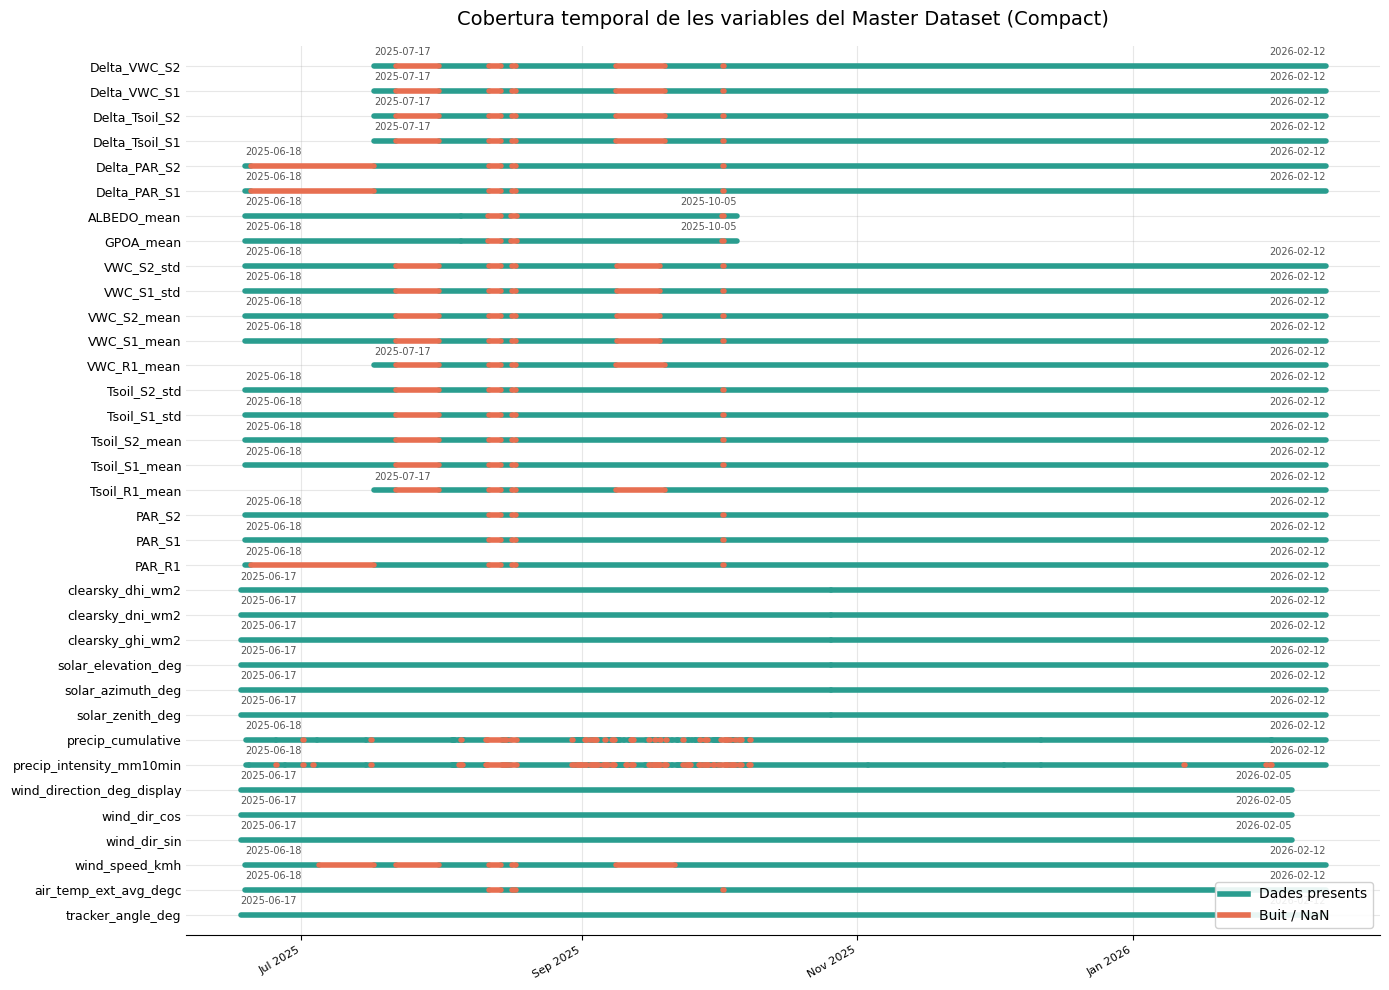

In [55]:
# ============================================================
# Visualització de la Cobertura Temporal del Master Dataset
# ============================================================
fig, ax = plt.subplots(figsize=(14, 10)) # Més alçada per encabir les 34 columnes

labels_plotted = []

# Definim un buit com un salt superior al doble del BASE_FREQ (20 minuts)
threshold = pd.Timedelta(minutes=20)

for i, col in enumerate(compact.columns):
    # Ens quedem només amb els registres on la variable no és nula
    valid_data = compact[col].dropna()
    if valid_data.empty:
        continue
        
    first_real = valid_data.index[0]
    last_real  = valid_data.index[-1]
    
    # Calcular diferències de temps per detectar forats
    diffs = valid_data.index.to_series().diff()
    gap_mask = diffs > threshold
    segment_id = gap_mask.cumsum()
    
    # Dibuixar els segments continus de dades (Verd)
    for seg, group in valid_data.groupby(segment_id):
        ax.plot([group.index[0], group.index[-1]], [i, i],
                lw=4, solid_capstyle='round', color='#2A9D8F', zorder=2)
        
    # Dibuixar els buits identificats (Vermell)
    for gap_end in valid_data.index[gap_mask]:
        gap_start = valid_data.index[valid_data.index.get_loc(gap_end) - 1]
        ax.plot([gap_start, gap_end], [i, i],
                lw=4, solid_capstyle='round', color='#E76F51', zorder=3)
                
    # Afegir etiquetes de data (inici i fi) per a cada variable
    ax.text(first_real, i + 0.35, first_real.strftime('%Y-%m-%d'),
            fontsize=7, color='#555', ha='left', va='bottom')
    ax.text(last_real,  i + 0.35, last_real.strftime('%Y-%m-%d'),
            fontsize=7, color='#555', ha='right', va='bottom')
            
    labels_plotted.append(col)

# Configuració dels eixos i aspecte general
ax.set_yticks(range(len(labels_plotted)))
ax.set_yticklabels(labels_plotted, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_title('Cobertura temporal de les variables del Master Dataset (Compact)', fontsize=14, pad=15)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', length=0)
ax.set_ylim(-0.8, len(labels_plotted) - 0.2)

# Llegenda
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='#2A9D8F', lw=4, label='Dades presents'),
    Line2D([0], [0], color='#E76F51', lw=4, label='Buit / NaN'),
], fontsize=10, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'cobertura_temporal_master_dataset.png', dpi=150, bbox_inches='tight')
plt.show()